In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os



<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


In [2]:
fd = pd.read_csv("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/generate_occupancy/mapped_schedules/mapped_H09_cleaned_2013.csv")

In [72]:
import pandas as pd
import numpy as np
import os
import glob

# Directories for house-level schedules
directory = "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/generate_occupancy/mapped_schedules"
out_directory = "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/generate_occupancy/hybrid_schedules"
os.makedirs(out_directory, exist_ok=True)

# Room substitution mapping
substitutes = {
    'H09': {'hall_upstairs': 'hall_downstairs'},
    'H11': {'hall_upstairs': 'hall_downstairs', 'bedroom_1': 'bedroom_2'},
    'H28': {'hall_upstairs': 'hall_downstairs'},
    'H30': {'bedroom_3': 'bedroom_2'}
}

# Get all CSV files
csv_files = glob.glob(os.path.join(directory, "*.csv"))

for file in csv_files:
    # Load the house schedule
    house_df = pd.read_csv(file, parse_dates=['UTC_Time']).set_index('UTC_Time')
    house_name = os.path.basename(file).split('_')[1]  # Extract house name (H09, H11, etc.)

    if house_name in substitutes:
        substitute_names = substitutes.get(house_name)
        for missing_room, present_room in substitute_names.items():
            # Ensure the present_room exists before substitution
            if present_room in house_df.columns:
                house_df[missing_room] = house_df[present_room]

    # Clip values between 0 and 1 if needed
    house_df = house_df.clip(0, 1)

    # Fractionalise each row
    row_sums = house_df.sum(axis=1)
    row_sums = row_sums.replace(0, 1)  # Replace zeros to avoid division by zero
    house_df = house_df.div(row_sums, axis=0)  # Fractionalise each row

    # Save the hybrid schedule
    output_filename = os.path.join(out_directory, f"{house_name}_hybrid_schedule.sch")
    house_df.to_csv(output_filename)

    print(f"Hybrid schedule for {house_name} saved to '{output_filename}'.")


Hybrid schedule for H11 saved to '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/generate_occupancy/hybrid_schedules/H11_hybrid_schedule.sch'.
Hybrid schedule for H30 saved to '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/generate_occupancy/hybrid_schedules/H30_hybrid_schedule.sch'.
Hybrid schedule for H33 saved to '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/generate_occupancy/hybrid_schedules/H33_hybrid_schedule.sch'.
Hybrid schedule for H09 saved to '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/generate_occupancy/hybrid_schedules/H09_hybrid_schedule.sch'.
Hybrid schedule for H28 saved to '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/generate_occupancy/hybrid_schedules/H28_hybrid_schedule.sch'.
Hybrid schedule for H43 saved to '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/generate_occupancy/hybrid_schedules/H43_hybrid_schedule.sch'.


In [76]:
file = "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/generate_occupancy/hybrid_schedules/H33_hybrid_schedule.sch"

fd = pd.read_csv(file)

In [77]:
file2 ="/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/generate_occupancy/hybrid_schedules/H30_hybrid_schedule.sch"

fd2 = pd.read_csv(file2)

In [79]:
fd2

,UTC_Time,hall_downstairs,front_room,kitchen,backroom,bedroom_1,hall_upstairs,bathroom,bedroom_2,bedroom_3
0,2013-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2013-01-01 00:01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2013-01-01 00:02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2013-01-01 00:03:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2013-01-01 00:04:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
525595,2013-12-31 23:55:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525596,2013-12-31 23:56:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525597,2013-12-31 23:57:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
525598,2013-12-31 23:58:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [80]:
fd["hall_upstairs"] = fd2["hall_upstairs"]
fd["hall_downstairs"] = fd2["hall_downstairs"]


In [81]:
fd.to_csv(file, index=False)

In [3]:
directory = "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/generate_occupancy/mapped_schedules"
rooms = [
    'hall_downstairs', 'hall_upstairs', 'front_room', 'kitchen', 'backroom',
    'bedroom_1', 'bedroom_2', 'bedroom_3', 'bathroom'
]
mapping = {
    'Hall (Down stairs)': 'hall_downstairs', 'Hall (Upstairs)': 'hall_upstairs',
    'Front Room': 'front_room', 'Kitchen': 'kitchen', 'Backroom': 'backroom',
    'Bedroom 1': 'bedroom_1', 'Bedroom 2': 'bedroom_2',
    'Bedroom 3': 'bedroom_3', 'Bathroom 1': 'bathroom'
}
reverse_mapping = {v: k for k, v in mapping.items()}



csv_files = glob.glob(os.path.join(directory, "*.csv"))

house_dataframes = {}
for file in csv_files:
    house_name = os.path.basename(file).split('_')[1]
    house_df = pd.read_csv(file)
    house_df.columns = house_df.columns.str.replace(r'^H\d{2}_', '', regex=True)
    house_df.rename(columns=mapping, inplace=True)
    house_dataframes[house_name] = house_df

In [4]:
def calculate_yearly_occupancy_distribution(df):
    df['UTC_Time'] = pd.to_datetime(df['UTC_Time'])
    waking_hours_data = df.set_index('UTC_Time').between_time('06:00', '23:00')
    occupancy_distribution = {}
    for room in rooms:
        if room in waking_hours_data.columns:
            occupied_count = len(waking_hours_data[waking_hours_data[room] > 0])
            total_count = len(waking_hours_data)
            occupancy_percentage = (occupied_count / total_count) * 100 if total_count > 0 else 0
            occupancy_distribution[room] = occupancy_percentage
        else:
            occupancy_distribution[room] = None
    return occupancy_distribution

In [5]:


csv_files = glob.glob(os.path.join(directory, "*.csv"))

house_dataframes = {}
for file in csv_files:
    house_name = os.path.basename(file).split('_')[1]
    house_df = pd.read_csv(file)
    house_df.columns = house_df.columns.str.replace(r'^H\d{2}_', '', regex=True)
    house_df.rename(columns=mapping, inplace=True)
    house_dataframes[house_name] = house_df


house_dataframes = dict(sorted(house_dataframes.items(), key=lambda item: item[0]))
occupancy_distributions = {house: calculate_yearly_occupancy_distribution(df) for house, df in house_dataframes.items()}

long_df = pd.DataFrame({
    'Room': list(occupancy_distributions[next(iter(occupancy_distributions))].keys()) * len(occupancy_distributions),
    'Occupancy': [value for dist in occupancy_distributions.values() for value in dist.values()],
    'House': [house for house in occupancy_distributions.keys() for _ in occupancy_distributions[house].values()]
})
long_df = long_df[long_df['Occupancy'].notna()]

room_order = long_df.groupby('Room')['Occupancy'].mean().sort_values(ascending=False).index




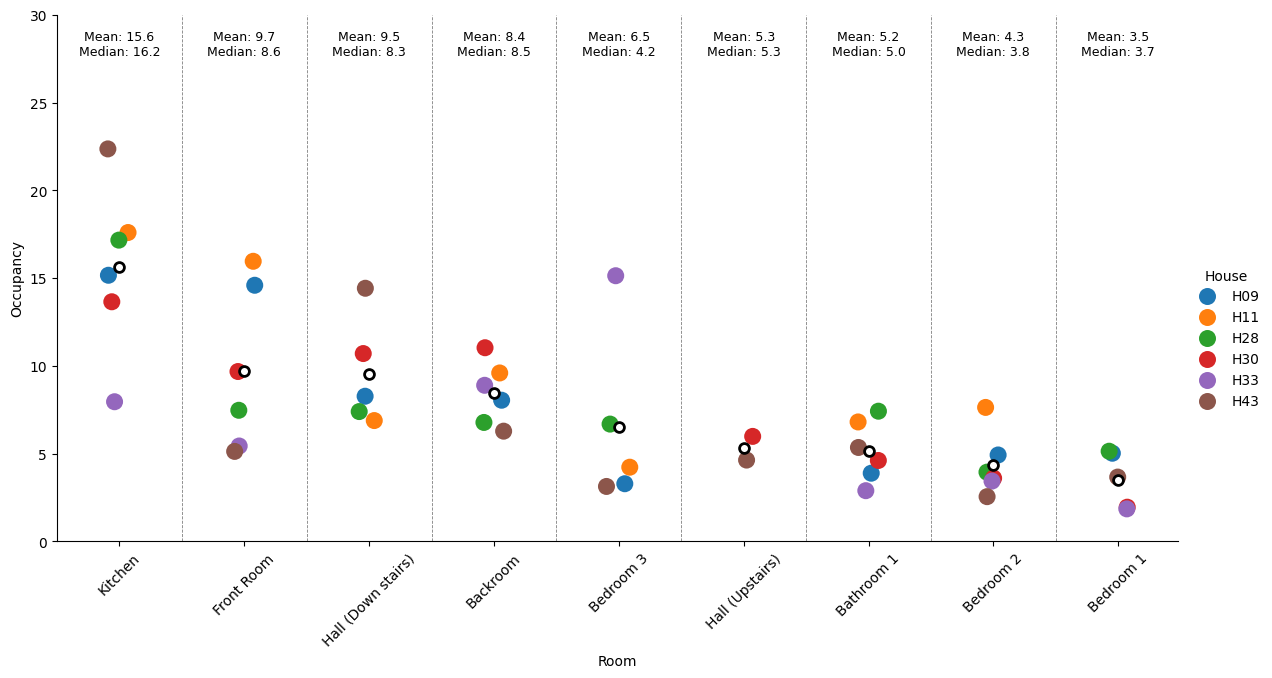

In [6]:


# Assuming 'long_df', 'room_order', and 'reverse_mapping' are predefined
g = sns.catplot(
    data=long_df, x='Room', y='Occupancy', hue='House', kind='strip', height=6, aspect=2,
    order=room_order, s=150
)

# Set x-tick labels
updated_labels = [reverse_mapping.get(room, room) for room in room_order]
g.set_xticklabels(updated_labels, rotation=45)

# Calculate means and medians
room_stats = long_df.groupby('Room')['Occupancy'].agg(['mean', 'median'])

# Overlay hollow points for means with higher zorder
sns.scatterplot(
    x=room_stats.index, y=room_stats['mean'], marker='o', edgecolor='black', s=50,
    linewidth=2, color='white', ax=g.ax, label='Mean', legend=False, zorder=3
)

# Annotate text for mean and median
for index, row in room_stats.iterrows():
    g.ax.text(
        x=room_order.get_loc(index), y=27.5, s=f"Mean: {row['mean']:.1f}\nMedian: {row['median']:.1f}",
        ha='center', va='bottom', fontsize=9, color='black'
    )

# Add vertical separators to distinguish rooms
for i in range(len(room_order) - 1):
    plt.axvline(x=i + 0.5, color='grey', linestyle='--', linewidth=0.6)  # Add a vertical dashed line between each room

g.ax.set_ylim(0, 30)
plt.show()


In [82]:


# Assuming `calculate_yearly_occupancy_distribution` and `long_df` are predefined elsewhere
synthetic_directory = "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/generate_occupancy/hybrid_schedules/"

csv_files = glob.glob(os.path.join(synthetic_directory, "*.sch"))

# List to collect all replicate DataFrames
all_replicates = []

# Calculate percentage for each replicate and store in list
for i, file_path in enumerate(csv_files):
    # Load each replicate
    replicate_df = pd.read_csv(file_path, parse_dates=['UTC_Time'])
    # Calculate the percentage of values > 0 for each room in the replicate
    percentage_rep = calculate_yearly_occupancy_distribution(replicate_df)

    # Convert the percentage results to a DataFrame
    source_label = 'H28' if i == 2 else f'rep {i}'  # Annotate the first replicate as 'H28'
    df_rep_long = pd.DataFrame({
        'Room': list(percentage_rep.keys()),
        'Percentage': list(percentage_rep.values()),
        'Source': source_label
    })
    # Append each replicate DataFrame to the list
    all_replicates.append(df_rep_long)

/tmp/ipykernel_12637/3923189364.py:15: UserWarning: The palette list has more values (11) than needed (6), which may not be intended.
  sns.stripplot(data=df_rep_long_combined, x='Room', y='Percentage', hue='Source', jitter=0.001, dodge=True, order=room_order, s=7, palette=colours, ax=ax)


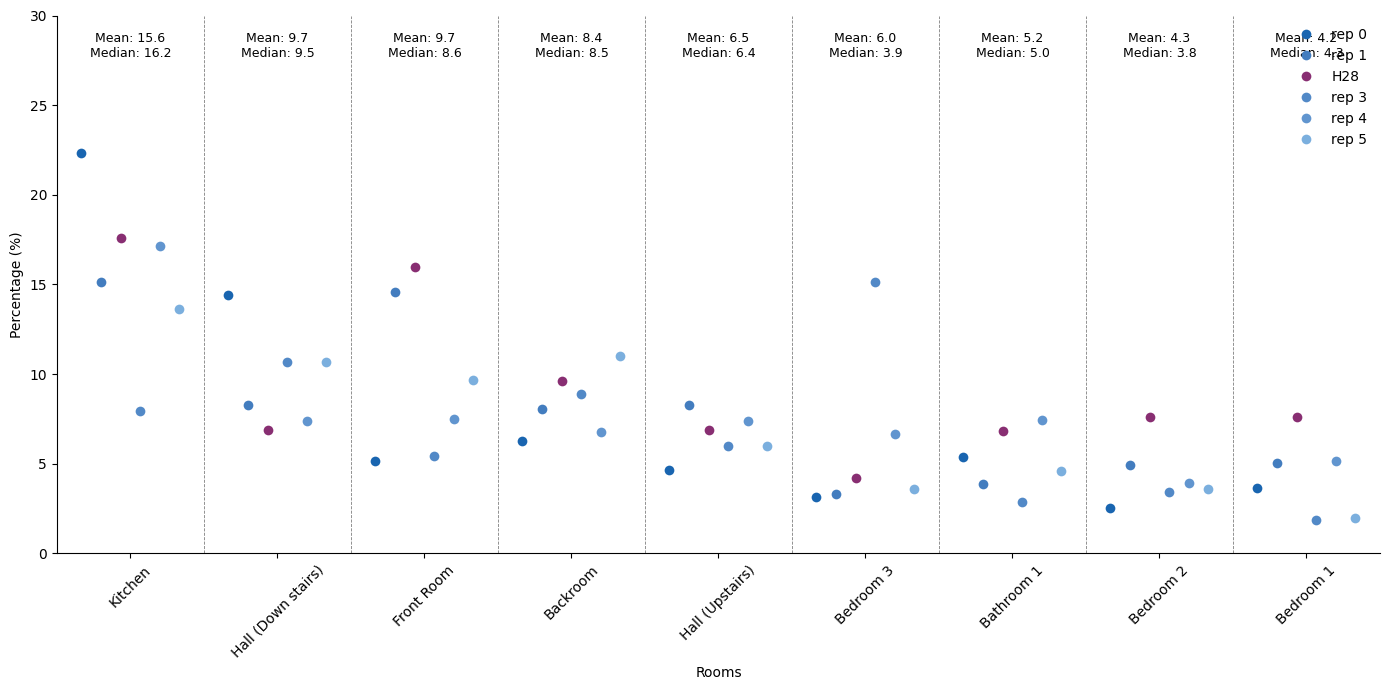

: 

In [84]:


# Concatenate all replicate DataFrames into one
df_rep_long_combined = pd.concat(all_replicates, ignore_index=True)

# Define the room order based on the mean occupancy in `long_df`
room_order = df_rep_long_combined.groupby('Room')['Percentage'].mean().sort_values(ascending=False).index

# Set x-tick labels
updated_labels = [reverse_mapping.get(room, room) for room in room_order]

# Define custom colours
colours = ['#1965B0', '#437DBF', '#882E72', '#5289C7', '#6195CF', '#7BAFDE', '#4EB265', '#90C987', '#CAE0AB', '#F7F056', '#F7CB45']

# Plot using Seaborn's stripplot with sorted room order and custom colours
fig, ax = plt.subplots(figsize=(14, 7))  # Create figure and axis objects
sns.stripplot(data=df_rep_long_combined, x='Room', y='Percentage', hue='Source', jitter=0.001, dodge=True, order=room_order, s=7, palette=colours, ax=ax)

# Add vertical separators to distinguish rooms
for i in range(len(room_order) - 1):
    ax.axvline(x=i + 0.5, color='grey', linestyle='--', linewidth=0.6)  # Add a vertical dashed line between each room

# Set custom x-tick labels and rotation
ax.set_xticks(range(len(updated_labels)))
ax.set_xticklabels(updated_labels, rotation=45)

# Customise spines and other aesthetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Calculate mean and median for each room
synthetic_room_stats = df_rep_long_combined.groupby('Room')['Percentage'].agg(['mean', 'median'])

# Annotate text for mean and median
for room in room_order:
    mean_value = synthetic_room_stats.loc[room, 'mean']
    median_value = synthetic_room_stats.loc[room, 'median']
    ax.text(
        x=room_order.get_loc(room), y=27.5,
        s=f"Mean: {mean_value:.1f}\nMedian: {median_value:.1f}",
        ha='center', va='bottom', fontsize=9, color='black'
    )

# Axis labels
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Rooms')
plt.ylim(0,30)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [8]:


# Assuming `calculate_yearly_occupancy_distribution` and `long_df` are predefined elsewhere
synthetic_directory = "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/generate_occupancy/synthetic_schedules/synthetic_occupancy/old_reps"
rep_files = glob.glob(f"{synthetic_directory}/rep_*.sch")

# List to collect all replicate DataFrames
all_replicates = []

# Calculate percentage for each replicate and store in list
for i, file_path in enumerate(rep_files):
    # Load each replicate
    replicate_df = pd.read_csv(file_path, parse_dates=['UTC_Time'])
    # Calculate the percentage of values > 0 for each room in the replicate
    percentage_rep = calculate_yearly_occupancy_distribution(replicate_df)

    # Convert the percentage results to a DataFrame
    source_label = 'H28' if i == 0 else f'rep {i}'  # Annotate the first replicate as 'H28'
    df_rep_long = pd.DataFrame({
        'Room': list(percentage_rep.keys()),
        'Percentage': list(percentage_rep.values()),
        'Source': source_label
    })
    # Append each replicate DataFrame to the list
    all_replicates.append(df_rep_long)

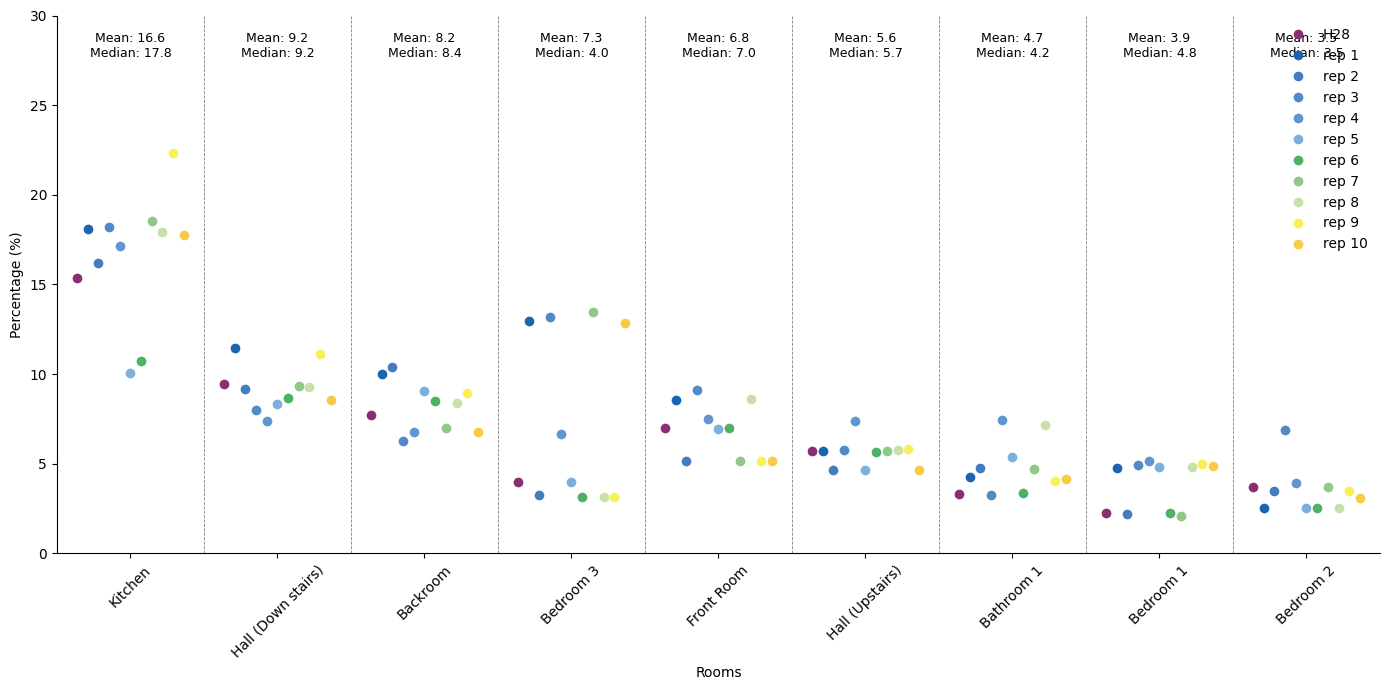

In [9]:


# Concatenate all replicate DataFrames into one
df_rep_long_combined = pd.concat(all_replicates, ignore_index=True)

# Define the room order based on the mean occupancy in `long_df`
room_order = df_rep_long_combined.groupby('Room')['Percentage'].mean().sort_values(ascending=False).index

# Set x-tick labels
updated_labels = [reverse_mapping.get(room, room) for room in room_order]

# Define custom colours
colours = ['#882E72', '#1965B0', '#437DBF', '#5289C7', '#6195CF', '#7BAFDE', '#4EB265', '#90C987', '#CAE0AB', '#F7F056', '#F7CB45']

# Plot using Seaborn's stripplot with sorted room order and custom colours
fig, ax = plt.subplots(figsize=(14, 7))  # Create figure and axis objects
sns.stripplot(data=df_rep_long_combined, x='Room', y='Percentage', hue='Source', jitter=0.001, dodge=True, order=room_order, s=7, palette=colours, ax=ax)

# Add vertical separators to distinguish rooms
for i in range(len(room_order) - 1):
    ax.axvline(x=i + 0.5, color='grey', linestyle='--', linewidth=0.6)  # Add a vertical dashed line between each room

# Set custom x-tick labels and rotation
ax.set_xticks(range(len(updated_labels)))
ax.set_xticklabels(updated_labels, rotation=45)

# Customise spines and other aesthetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Calculate mean and median for each room
synthetic_room_stats = df_rep_long_combined.groupby('Room')['Percentage'].agg(['mean', 'median'])

# Annotate text for mean and median
for room in room_order:
    mean_value = synthetic_room_stats.loc[room, 'mean']
    median_value = synthetic_room_stats.loc[room, 'median']
    ax.text(
        x=room_order.get_loc(room), y=27.5,
        s=f"Mean: {mean_value:.1f}\nMedian: {median_value:.1f}",
        ha='center', va='bottom', fontsize=9, color='black'
    )

# Axis labels
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Rooms')
plt.ylim(0,30)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()